<a href="https://colab.research.google.com/github/Shashwat7785/ML_projects/blob/main/Myntra_Product_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
df = pd.read_csv("myntra_visual_data.csv")


In [ ]:
df.head()

,Brand,Product Name,Price,Offer,Rating Summary,Product Link
0,HIGHLANDER,Slim Fit Casual Shirt,Rs. 433,(86% OFF),4.7 | 23,https://www.myntra.com/shirts/highlander/highl...
1,HIGHLANDER,Checked Slim Fit Casual Shirt,Rs. 323,(82% OFF),4.3 | 267,https://www.myntra.com/shirts/highlander/highl...
2,HIGHLANDER,Slim Fit Opaque Casual Shirt,Rs. 495,(69% OFF),4.2 | 212.4k,https://www.myntra.com/shirts/highlander/highl...
3,HIGHLANDER,Slim Fit Casual Shirt,Rs. 610,(53% OFF),4.3 | 120.3k,https://www.myntra.com/shirts/highlander/highl...
4,HIGHLANDER,Relaxed Fit Cotton Shirt,Rs. 569,(81% OFF),4.1 | 87,https://www.myntra.com/shirts/highlander/highl...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Brand           290 non-null    object
 1   Product Name    290 non-null    object
 2   Price           290 non-null    object
 3   Offer           350 non-null    object
 4   Rating Summary  350 non-null    object
 5   Product Link    288 non-null    object
dtypes: object(6)
memory usage: 16.5+ KB


In [ ]:
df.isna().sum()

,0
Brand,60
Product Name,60
Price,60
Offer,0
Rating Summary,0
Product Link,62


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 288 entries, 0 to 349
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Brand           288 non-null    object
 1   Product Name    288 non-null    object
 2   Price           288 non-null    object
 3   Offer           288 non-null    object
 4   Rating Summary  288 non-null    object
 5   Product Link    288 non-null    object
dtypes: object(6)
memory usage: 15.8+ KB


Regex : regular expression pattern

Character Classes : These tell the engine what type of character to look for:

. : Matches any single character except a new line.

\d : Matches any digit (0–9).

\w : Matches any alphanumeric character (letters, numbers, underscores).\s : Matches any whitespace (spaces, tabs, newlines).

[abc] : Matches any one character inside the brackets (a, b, or c).

[^abc] : Matches any one character not inside the brackets


In [ ]:
def num_Price(s):
  #re.sub(pattern, replacement, string)
  clean = re.sub(r'[^\d]' , "" , s)
  return float(clean)

In [ ]:
df['Clean_Price'] = df['Price'].apply(num_Price)

In [ ]:
df['Clean_Price'].describe()

,Clean_Price
count,288.000000
mean,807.975694
std,329.197868
min,154.000000
25%,578.000000
50%,804.000000
75%,959.000000
max,3799.000000


In [ ]:
print(f"cheapest shirt = ", {df[df['Clean_Price'] == df['Clean_Price'].min()]['Product Name'].values[0]})
print(f"expensive shirt = ", {df[df['Clean_Price'] == df['Clean_Price'].max()]['Product Name'].values[0]})

cheapest shirt =  {'Men Casual Cotton Shirt'}
expensive shirt =  {'Men Spread Collar Linen Shirt'}


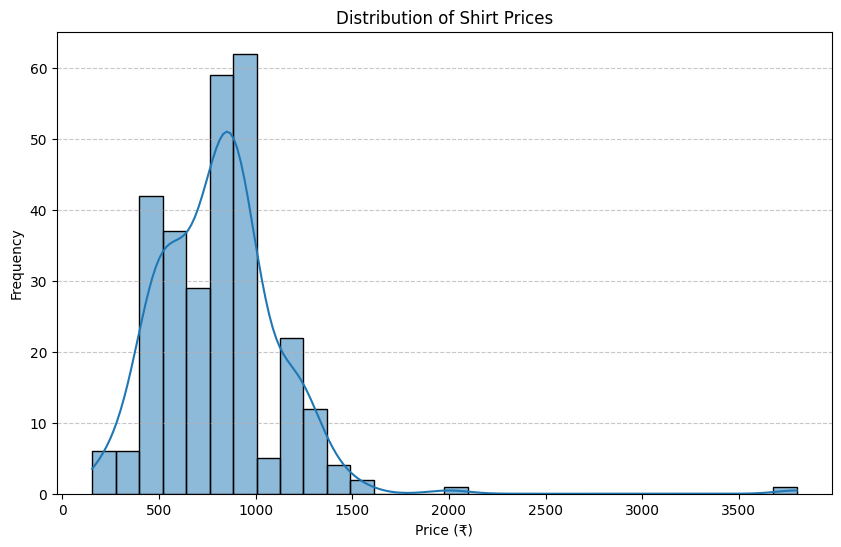

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Clean_Price'], bins=30, kde=True)
plt.title('Distribution of Shirt Prices')
plt.xlabel('Price (₹)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def find_pattern(name):
    name = str(name).lower()
    if 'check' in name: return 'Checked'
    if 'stripe' in name: return 'Striped'
    if 'solid' in name: return 'Solid'
    if 'print' in name: return 'Printed'
    if 'plain' in name: return 'Plain'
    if 'canvas' in name: return 'Canvas'
    if 'slim' in name: return 'Slim'
    if 'fit' in name: return 'Fit'
    if 'cotton' in name: return 'Cotton'
    if 'silk' in name: return 'Silk'
    return 'Other'

In [ ]:
df['Pattern'] = df['Product Name'].apply(find_pattern)

print("\n--- Pattern Breakdown ---")
print(df['Pattern'].value_counts())


--- Pattern Breakdown ---
Pattern
Other      76
Slim       67
Cotton     47
Checked    34
Solid      18
Fit        17
Striped    17
Printed    12
Name: count, dtype: int64


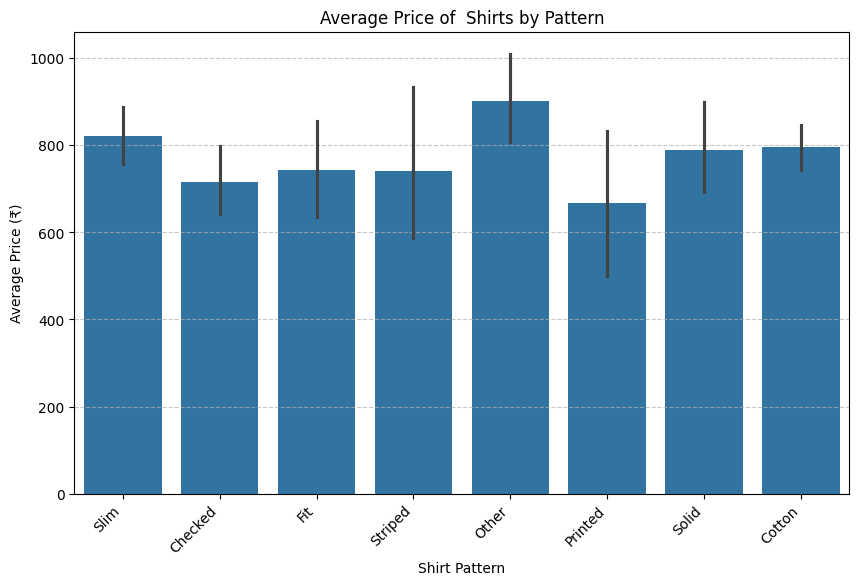

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Pattern', y='Clean_Price')

plt.title('Average Price of  Shirts by Pattern')
plt.xlabel('Shirt Pattern')
plt.ylabel('Average Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df['Brand'].value_counts()

,count
Brand,
HIGHLANDER,60
Allen Solly,50
Snitch,50
Mast & Harbour,50
Campus Sutra,38
Crimsoune Club,25
Roadster,13
Being Human,1
Powerlook,1


In [ ]:
df.groupby("Brand")["Clean_Price"].mean().sort_values(ascending=False)

,Clean_Price
Brand,
Snitch,1102.560000
Powerlook,1055.000000
Crimsoune Club,1039.600000
Allen Solly,961.080000
Being Human,835.000000
Campus Sutra,735.421053
Mast & Harbour,711.640000
Roadster,565.692308
HIGHLANDER,512.550000


In [ ]:
df['Mean Brand Price'] = df.groupby("Brand")["Clean_Price"].transform("mean")

In [ ]:
brand_price_stats = df.groupby('Brand')['Clean_Price'].describe()
display(brand_price_stats)

,count,mean,std,min,25%,50%,75%,max
Brand,,,,,,,,
Allen Solly,50.0,961.080000,159.044448,764.0,863.00,911.0,959.00,1549.0
Being Human,1.0,835.000000,NaN,835.0,835.00,835.0,835.00,835.0
Campus Sutra,38.0,735.421053,168.046588,398.0,616.50,835.0,879.00,911.0
Crimsoune Club,25.0,1039.600000,148.942942,759.0,899.00,999.0,1199.00,1199.0
HIGHLANDER,60.0,512.550000,166.745866,154.0,432.50,515.5,597.25,999.0
Mast & Harbour,50.0,711.640000,170.291678,399.0,579.75,759.0,799.00,1055.0
Powerlook,1.0,1055.000000,NaN,1055.0,1055.00,1055.0,1055.00,1055.0
Roadster,13.0,565.692308,94.602136,405.0,479.00,599.0,623.00,699.0
Snitch,50.0,1102.560000,485.276953,499.0,857.00,999.0,1286.75,3799.0


Text(0, 0.5, 'Average Price (₹)')

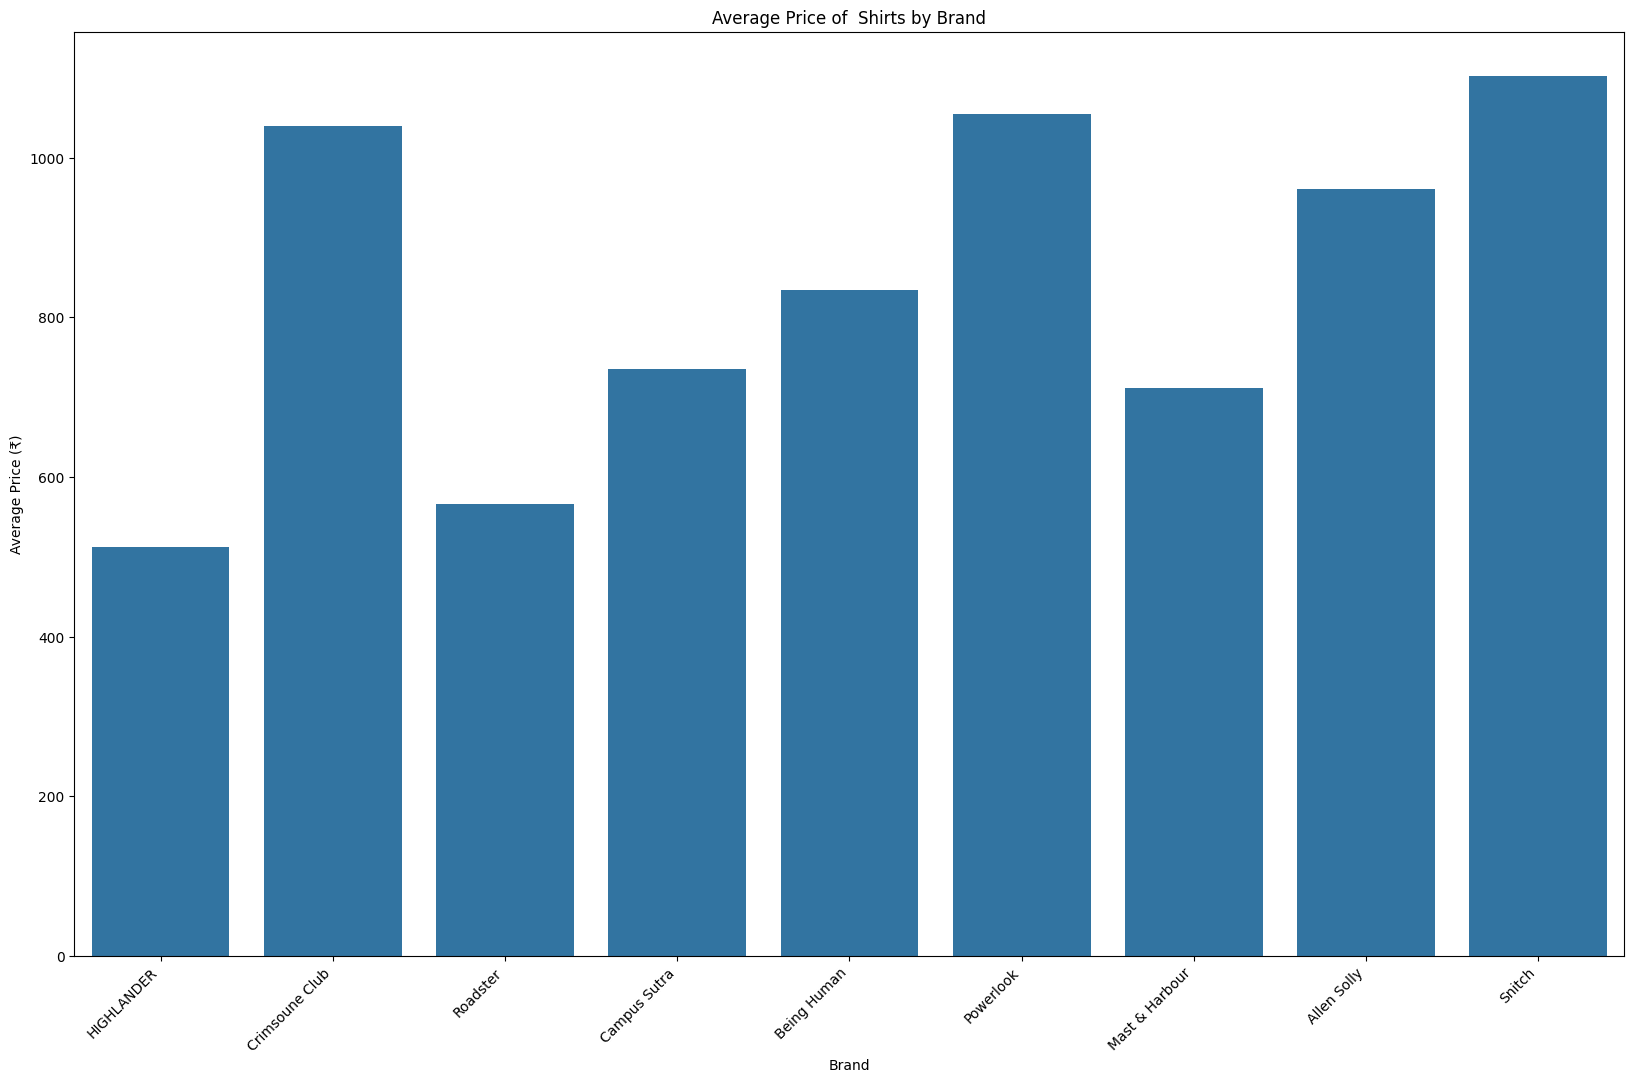

In [ ]:
plt.figure(figsize=(20, 12))
sns.barplot(data=df, x='Brand', y='Mean Brand Price')
plt.xticks(rotation=45, ha='right') #Rotate brand names by 45 degrees and align them to the right
plt.title('Average Price of  Shirts by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price (₹)')


Now, let's analyze the `Offer` column. We will extract the percentage value from the string.

In [ ]:
def extract_offer_percentage(offer_string):
    try:
        # Regex to find numbers followed by '%' within parentheses
        match = re.search(r'\((\d+)% OFF\)', offer_string)
        if match:
            return int(match.group(1))
        return None
    except:
        return None

df['Offer_percentage'] = df['Offer'].apply(extract_offer_percentage)

In [ ]:
print("\n--- Offer Percentage Breakdown ---")
print(df['Offer_percentage'].value_counts())



--- Offer Percentage Breakdown ---
Offer_percentage
52.0    23
50.0    20
53.0    20
56.0    19
67.0    12
71.0    10
60.0    10
40.0     9
68.0     7
64.0     7
72.0     6
49.0     6
62.0     6
76.0     6
66.0     6
65.0     4
90.0     4
55.0     4
74.0     3
61.0     3
79.0     3
75.0     3
70.0     3
82.0     3
86.0     3
89.0     3
69.0     2
77.0     2
81.0     2
85.0     2
84.0     2
80.0     2
42.0     2
57.0     2
88.0     1
23.0     1
51.0     1
78.0     1
43.0     1
54.0     1
73.0     1
6.0      1
48.0     1
Name: count, dtype: int64


In [ ]:
display(df['Offer_percentage'].describe())

,Offer_percentage
count,228.000000
mean,61.271930
std,12.898304
min,6.000000
25%,52.000000
50%,60.000000
75%,70.250000
max,90.000000


Now let's visualize the distribution of offer percentages and how they relate to the `Clean_Price`.

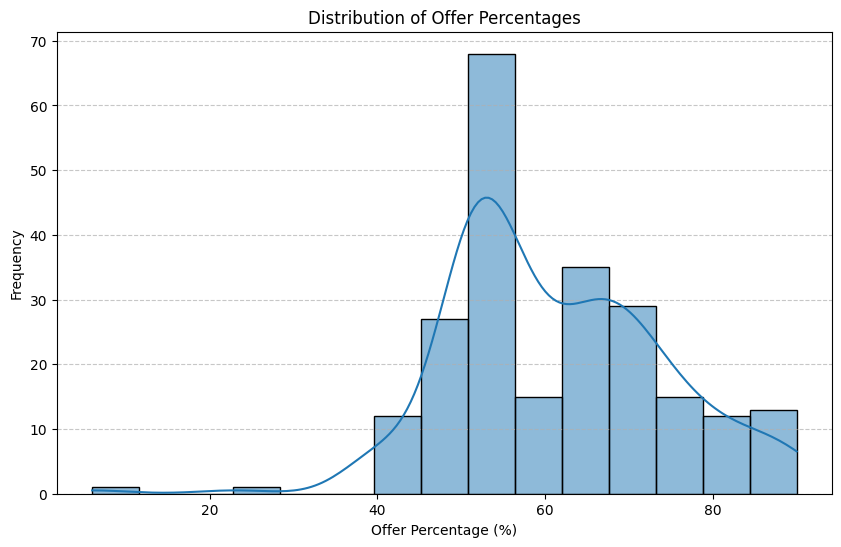

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Offer_percentage'], bins=15, kde=True)
plt.title('Distribution of Offer Percentages')
plt.xlabel('Offer Percentage (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

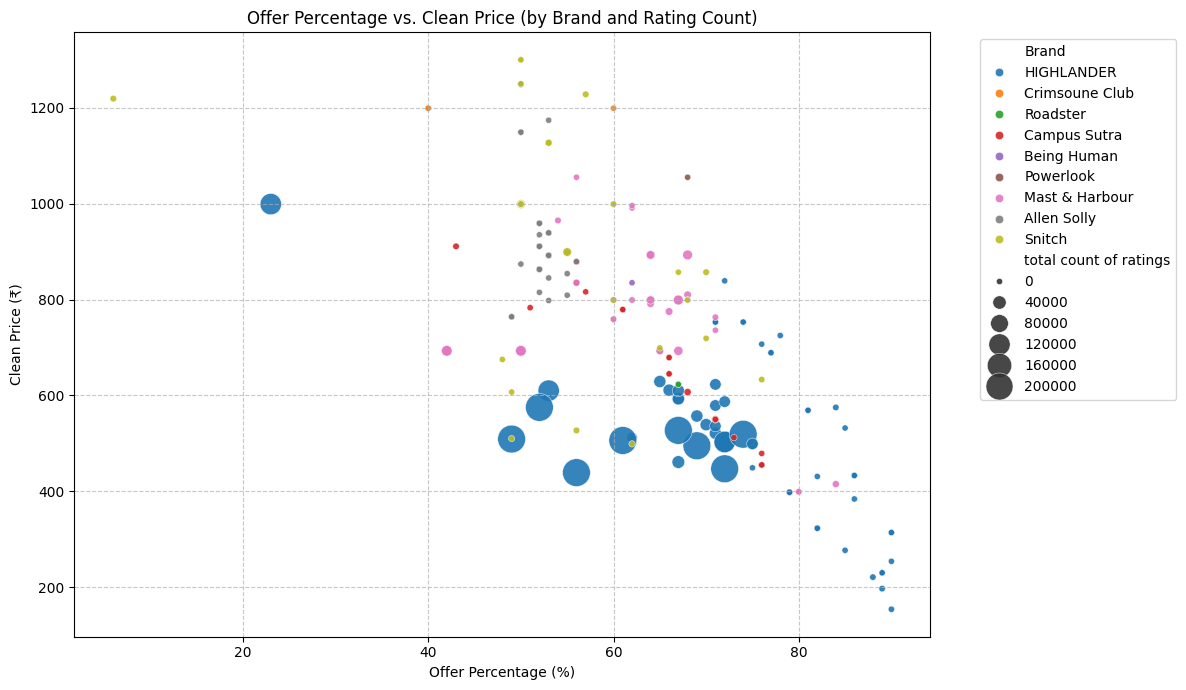

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Offer_percentage', y='Clean_Price', data=df, hue='Brand', size='total count of ratings', sizes=(20, 400), alpha=0.9)
plt.title('Offer Percentage vs. Clean Price (by Brand and Rating Count)')
plt.xlabel('Offer Percentage (%)')
plt.ylabel('Clean Price (₹)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Now, let's analyze the Rating column

In [ ]:
df['Rating Summary']

,Rating Summary
0,4.7 | 23
1,4.3 | 267
2,4.2 | 212.4k
3,4.3 | 120.3k
4,4.1 | 87
...,...
345,4.3 | 20
346,4 | 8
347,4.5 | 34
348,4.3 | 2.2k


In [ ]:
def clean_rating_count(rating_summary):
    if  "No Ratings" in rating_summary:
        return 0

    # Extract the count part after the "|" symbol
    try:
        count_str = rating_summary.split('|')[1].strip().lower()

        # Handle the "k" abbreviation for thousands
        if 'k' in count_str:
            return int(float(count_str.replace('k', '')) * 1000)
        return int(count_str)
    except:
        return 0

# Example mapping: "4.1 | 1.2k" becomes 1200

In [ ]:
def star_rating_count(rating_summary):
    if  "No Ratings" in rating_summary:
        return 0

    try:
        count_str = rating_summary.split('|')[0]

        return float(count_str)
    except:
        return 0

In [ ]:
df["total count of ratings"] = df["Rating Summary"].apply(clean_rating_count)

In [ ]:
df["star ratings"] = df["Rating Summary"].apply(star_rating_count)

In [ ]:
df['star ratings'].value_counts()

,count
star ratings,
4.3,62
4.2,48
0.0,41
4.4,32
4.1,28
4.0,21
4.5,20
4.6,9
3.9,6


In [ ]:
df.groupby("Brand")["star ratings"].mean().sort_values(ascending=False)

,star ratings
Brand,
Powerlook,4.300000
HIGHLANDER,4.243333
Campus Sutra,4.071053
Mast & Harbour,4.030000
Being Human,3.900000
Allen Solly,3.754000
Roadster,3.600000
Snitch,3.128000
Crimsoune Club,1.624000


In [ ]:
df.groupby("Brand")["total count of ratings"].mean().sort_values(ascending=False)

,total count of ratings
Brand,
HIGHLANDER,46256.250000
Roadster,19170.846154
Mast & Harbour,10012.820000
Snitch,1307.780000
Campus Sutra,601.815789
Allen Solly,77.380000
Powerlook,42.000000
Being Human,26.000000
Crimsoune Club,7.880000


Now, let's analyze the `star ratings` and `total count of ratings` columns. We will visualize their distributions and explore their relationships with `Clean_Price` and `Brand`.

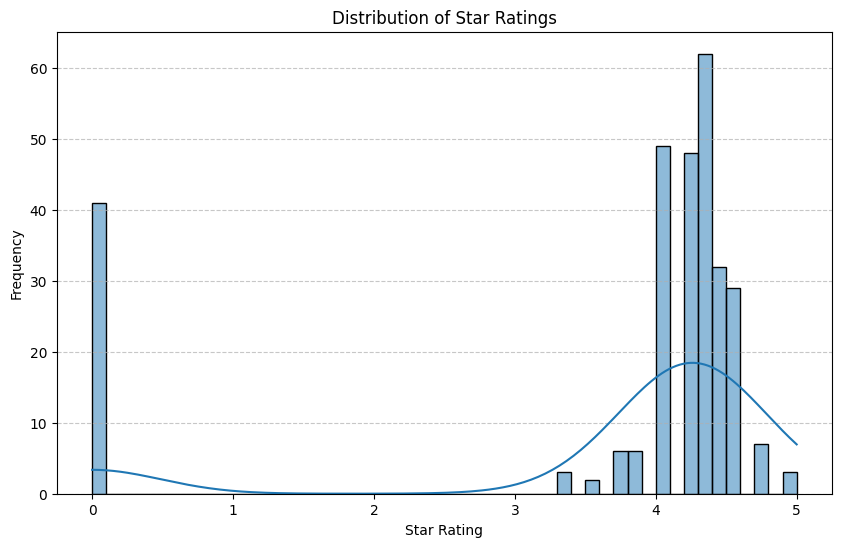

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['star ratings'], bins=50, kde=True)
plt.title('Distribution of Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

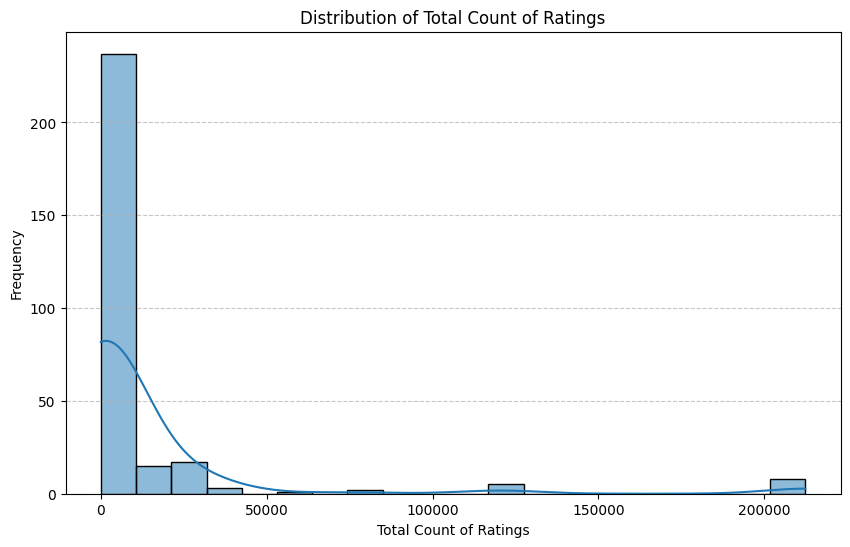

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['total count of ratings'], bins=20, kde=True)
plt.title('Distribution of Total Count of Ratings')
plt.xlabel('Total Count of Ratings')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

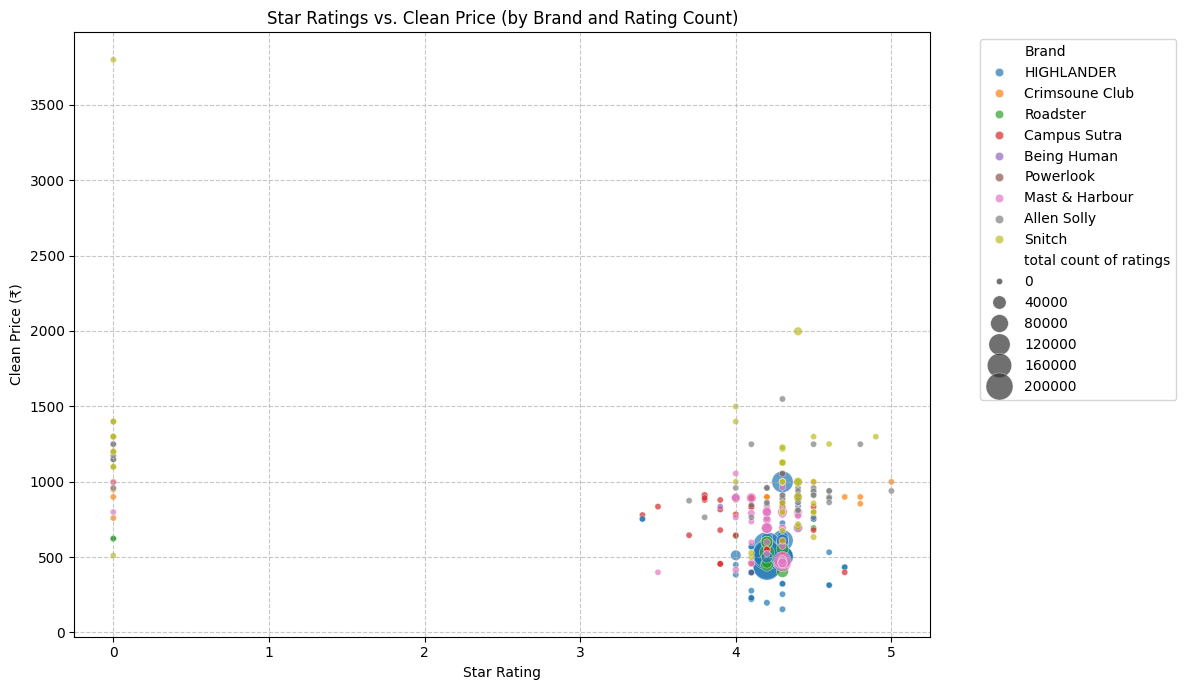

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='star ratings', y='Clean_Price', data=df, hue='Brand', size='total count of ratings', sizes=(20, 400), alpha=0.7)
plt.title('Star Ratings vs. Clean Price (by Brand and Rating Count)')
plt.xlabel('Star Rating')
plt.ylabel('Clean Price (₹)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Identifying "Bestsellers" vs. "New Arrivals"

To categorize products, we'll define 'Bestsellers' as products with high 'total count of ratings' and good 'star ratings'. 'New Arrivals' will be identified by a low 'total count of ratings' (assuming newer products haven't accumulated many ratings yet).

First, let's determine appropriate thresholds based on the quantiles of `total count of ratings` and a reasonable star rating.

In [ ]:
ratings_count_75th_percentile = df['total count of ratings'].quantile(0.75)
ratings_count_25th_percentile = df['total count of ratings'].quantile(0.25)

print(f"75th percentile of total count of ratings: {ratings_count_75th_percentile:.0f}")
print(f"25th percentile of total count of ratings: {ratings_count_25th_percentile:.0f}")

# Let's set a star rating threshold for bestsellers
star_rating_threshold = df['star ratings'].quantile(0.75)
print(f"Star rating threshold for bestsellers: {star_rating_threshold}")

75th percentile of total count of ratings: 3650
25th percentile of total count of ratings: 18
Star rating threshold for bestsellers: 4.3


In [ ]:
def categorize_product(row):
    if row['total count of ratings'] >= ratings_count_75th_percentile and row['star ratings'] >= star_rating_threshold:
        return 'Bestseller'
    elif row['total count of ratings'] <= ratings_count_25th_percentile:
        return 'New Arrival'
    else:
        return 'Other'

df['Product_Category'] = df.apply(categorize_product, axis=1)

print("\n--- Product Category Breakdown ---")
print(df['Product_Category'].value_counts())



--- Product Category Breakdown ---
Product_Category
Other          182
New Arrival     72
Bestseller      34
Name: count, dtype: int64


In [ ]:
display(df.groupby('Product_Category')['Clean_Price'].describe())

,count,mean,std,min,25%,50%,75%,max
Product_Category,,,,,,,,
Bestseller,34.0,660.147059,288.887955,405.0,487.25,593.0,697.5,1998.0
New Arrival,72.0,1071.819444,416.790464,314.0,899.00,1099.0,1211.5,3799.0
Other,182.0,731.214286,225.295222,154.0,550.00,799.0,892.0,1549.0


Now, let's visualize the distribution of these product categories across different brands and their average prices.

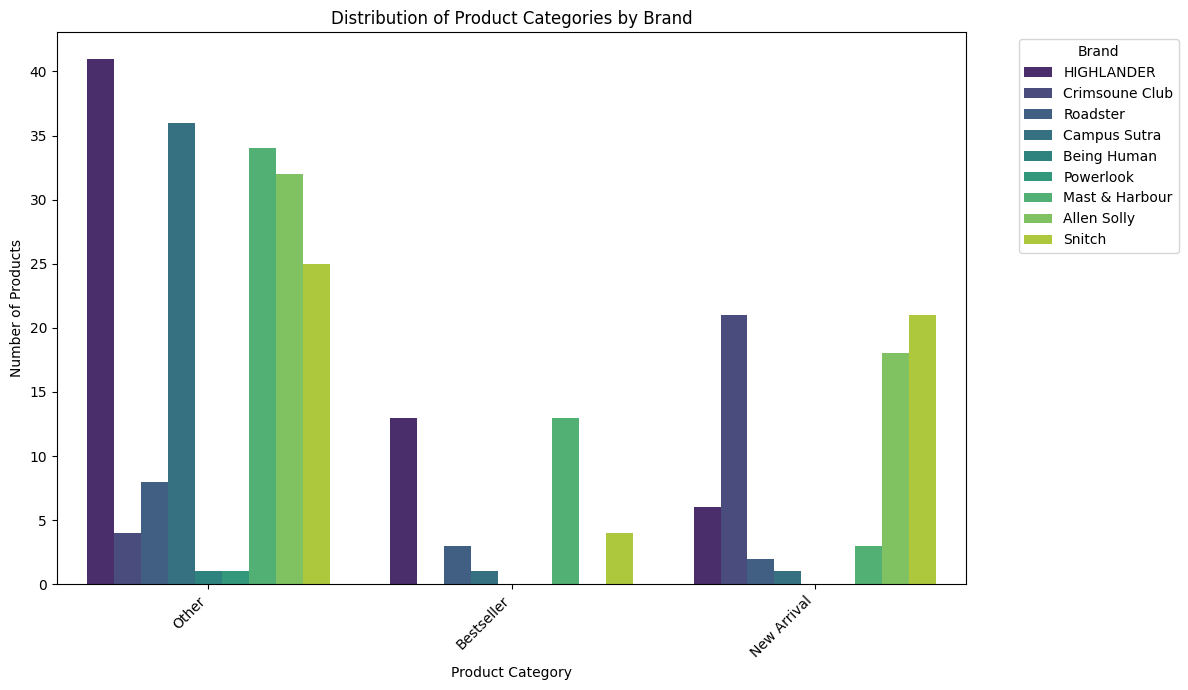

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Product_Category', hue='Brand', palette='viridis')
plt.title('Distribution of Product Categories by Brand')
plt.xlabel('Product Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

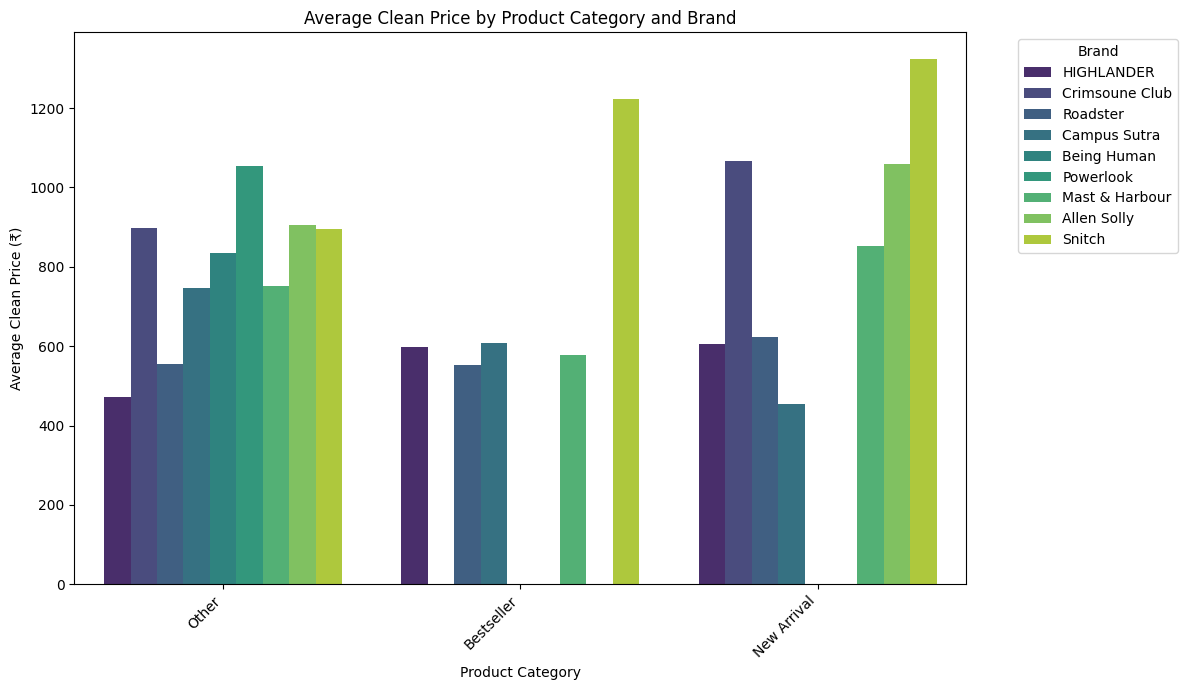

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(data=df, x='Product_Category', y='Clean_Price', hue='Brand', palette='viridis', errorbar=None)
plt.title('Average Clean Price by Product Category and Brand')
plt.xlabel('Product Category')
plt.ylabel('Average Clean Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()